# 02 — Model experiments (training families only)

**Lesson 2 in practice** ([notes](../docs/learning/02-text-classification-and-evaluation.md)).

Rules for this notebook:
- Data: snapshot `seed-v1` (hash-verified), minus everything in `holdout-sim-v1`, minus
  exact and near-duplicates of holdout texts.
- **The holdout is not touched here.** All comparisons use 3-fold **GroupKFold by
  household**: each ticket is predicted by a model that never saw its family.
- Every model is shown next to its baselines.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "backend"))

import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

from app.domain import Category
from ml.datasets import load_snapshot
from ml.evaluate import (expected_calibration_error, group_cv_predict, per_class_report,
                         reliability_table, summarise, threshold_table)
from ml.holdout import training_frame
from ml.models import EFFORT_ORDER, KeywordBaseline, TextModelConfig, build_text_classifier, majority_baseline

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
BLUE, INK, MUTED, SURFACE = "#2a78d6", "#0b0b0b", "#898781", "#fcfcfb"
BLUES = ["#f3f7fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

df = load_snapshot("seed-v1")
train, report = training_frame(df)
print(report)
X, groups = train["text"].to_numpy(), train["household_id"].to_numpy()
y_cat, y_eff = train["category"].to_numpy(), train["effort"].to_numpy()
CATS = [c.value for c in Category]
print(f"{len(train)} training tickets from {train['household_id'].nunique()} families")

AUTH_SECRET missing or short; using an insecure development secret


{'rows_in': 2400, 'excluded_holdout': 600, 'excluded_duplicate_of_holdout': 85, 'excluded_near_duplicate_of_holdout': 42, 'rows_out': 1673}
1673 training tickets from 9 families


## 1. Category: baselines

What a model has to beat. Remember: 7 classes, so random guessing gives macro-F1 ≈ 0.14.

In [2]:
def cv(estimator, y, ordinal=False):
    return summarise(y, group_cv_predict(estimator, X, y, groups), ordinal=ordinal)

baselines = pd.DataFrame({
    "majority": cv(majority_baseline(), y_cat),
    "keyword rules": cv(KeywordBaseline(), y_cat),
}).T
baselines

,n,accuracy,macro_f1,macro_f1_ci95
majority,1673,0.238,0.055,"(0.051, 0.059)"
keyword rules,1673,0.589,0.63,"(0.605, 0.653)"


## 2. Category: TF-IDF + logistic regression, small grid

Three feature types × four regularisation strengths × with/without class weights = 24
configurations, each scored with group cross-validation. We rank by macro-F1 but also
look at the confidence interval: differences smaller than the interval width are noise.

In [3]:
rows = []
for features, C, cw in itertools.product(["word", "char", "word+char"], [0.3, 1, 3, 10], [None, "balanced"]):
    config = TextModelConfig(features=features, C=C, class_weight=cw)
    rows.append({"features": features, "C": C, "class_weight": cw or "-", **cv(build_text_classifier(config), y_cat)})
grid = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
grid.head(12)

,features,C,class_weight,n,accuracy,macro_f1,macro_f1_ci95
23,word+char,10.0,balanced,1673,0.926,0.918,"(0.902, 0.931)"
21,word+char,3.0,balanced,1673,0.927,0.918,"(0.903, 0.933)"
19,word+char,1.0,balanced,1673,0.925,0.918,"(0.902, 0.933)"
14,char,10.0,-,1673,0.924,0.918,"(0.902, 0.933)"
22,word+char,10.0,-,1673,0.921,0.914,"(0.898, 0.929)"
20,word+char,3.0,-,1673,0.921,0.913,"(0.896, 0.928)"
17,word+char,0.3,balanced,1673,0.920,0.912,"(0.895, 0.927)"
15,char,10.0,balanced,1673,0.923,0.912,"(0.895, 0.927)"
11,char,1.0,balanced,1673,0.919,0.909,"(0.893, 0.924)"
12,char,3.0,-,1673,0.918,0.908,"(0.891, 0.923)"


In [4]:
best_row = grid.iloc[0]
BEST = TextModelConfig(features=best_row["features"], C=float(best_row["C"]),
                       class_weight=None if best_row["class_weight"] == "-" else best_row["class_weight"])
print("best configuration:", BEST)
by_features = grid.groupby("features")["macro_f1"].max().sort_values(ascending=False)
print("best macro-F1 per feature type:", by_features.round(3).to_dict())

best configuration: TextModelConfig(features='word+char', C=10.0, class_weight='balanced', mask_names=False, ordinal=False)
best macro-F1 per feature type: {'char': 0.918, 'word+char': 0.918, 'word': 0.891}


## 3. The best configuration up close

Per-class scores and the confusion matrix (rows = true category, columns = predicted).
Off-diagonal cells show which categories the model mixes up.

,precision,recall,f1,support
chores,0.930,0.965,0.947,398
groceries,0.961,0.980,0.970,352
kids,0.897,0.818,0.856,308
home_maintenance,0.914,0.924,0.919,288
finance,0.936,0.951,0.944,123
social,0.955,0.948,0.951,134
other,0.831,0.843,0.837,70


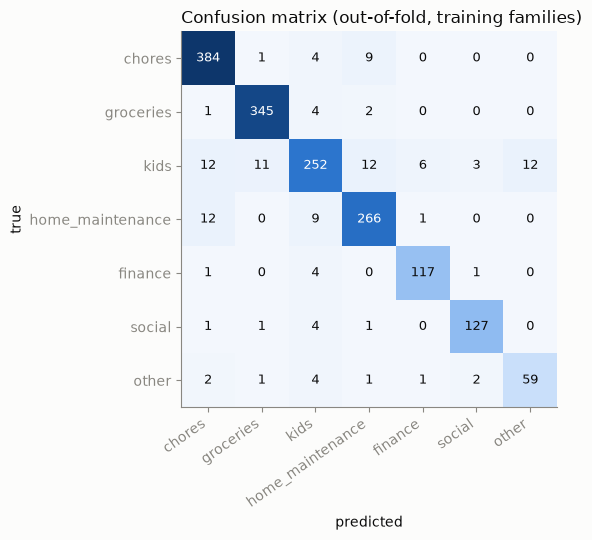

In [5]:
oof = group_cv_predict(build_text_classifier(BEST), X, y_cat, groups)
display(per_class_report(y_cat, oof, CATS))

cm = confusion_matrix(y_cat, oof, labels=CATS)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("b", BLUES))
ax.set_xticks(range(len(CATS)), CATS, rotation=35, ha="right")
ax.set_yticks(range(len(CATS)), CATS)
for i in range(len(CATS)):
    for j in range(len(CATS)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9, color="white" if cm[i, j] > cm.max() * 0.45 else INK)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix (out-of-fold, training families)", loc="left", color=INK)
plt.tight_layout()
plt.show()

### What did the model learn?

The strongest positive features per category (fitted on all training families). Good signs:
content words. Bad signs: names of people and pets, which only work within one family.

In [6]:
model = build_text_classifier(BEST).fit(X, y_cat)
vec, clf = model.named_steps["features"], model.named_steps["classifier"]
names = np.array(vec.get_feature_names_out())
top = {cls: ", ".join(repr(n.split("__")[-1]) for n in names[np.argsort(coef)[::-1][:10]])
       for cls, coef in zip(clf.classes_, clf.coef_)}
pd.Series(top, name="top features").to_frame()

,top features
chores,"'was', 'was', ' was', 'eten', ' wa', 'verschon..."
finance,"'betalen', 'overmaken', 'checken', 'vergelijke..."
groceries,"'en', 'halen', ' en ', 'voor', ' en', 'meeneme..."
home_maintenance,"'auto', 'smeren', 'fiet', 'fiets', 'dakgoot', ..."
kids,"'saar', 'noah', 'emma', 'finn', 'fleur', 'noor..."
other,"'kapper', 'paspoort', 'ik moet', 'controle', '..."
social,"'tje ', 'cadeautje', 'met', 'kadootje', 'buren..."


## 4. Experiment: mask names

EDA showed 34% of tickets mention a name. Does replacing names with a placeholder help the
model generalise to *other* families? If the score rises, the model was leaning on names.

In [7]:
masked = TextModelConfig(**{**BEST.as_dict(), "mask_names": True})
pd.DataFrame({"names kept": cv(build_text_classifier(BEST), y_cat),
              "names masked": cv(build_text_classifier(masked), y_cat)}).T

,n,accuracy,macro_f1,macro_f1_ci95
names kept,1673,0.926,0.918,"(0.902, 0.931)"
names masked,1673,0.933,0.93,"(0.916, 0.944)"


## 5. Effort

Effort is 80% `S`: watch the majority baseline's accuracy vs its macro-F1. Besides macro-F1
we look at the ordinal error (steps wrong) and whether `L` is ever found.

In [8]:
feat = BEST.features
effort_models = {
    "majority": majority_baseline(),
    "LR": build_text_classifier(TextModelConfig(features=feat, C=1)),
    "LR balanced": build_text_classifier(TextModelConfig(features=feat, C=1, class_weight="balanced")),
    "ordinal balanced": build_text_classifier(TextModelConfig(features=feat, C=1, class_weight="balanced", ordinal=True)),
    "LR balanced C=0.3": build_text_classifier(TextModelConfig(features=feat, C=0.3, class_weight="balanced")),
    "ordinal balanced C=0.3": build_text_classifier(TextModelConfig(features=feat, C=0.3, class_weight="balanced", ordinal=True)),
}
effort = pd.DataFrame({name: cv(m, y_eff, ordinal=True) for name, m in effort_models.items()}).T
effort

,n,accuracy,macro_f1,macro_f1_ci95,ordinal_mae,recall_L
majority,1673,0.795,0.295,"(0.291, 0.299)",0.218,0.0
LR,1673,0.883,0.525,"(0.506, 0.543)",0.124,0.0
LR balanced,1673,0.886,0.685,"(0.608, 0.75)",0.116,0.333
ordinal balanced,1673,0.893,0.714,"(0.643, 0.774)",0.11,0.476
LR balanced C=0.3,1673,0.879,0.673,"(0.597, 0.736)",0.124,0.333
ordinal balanced C=0.3,1673,0.886,0.664,"(0.598, 0.726)",0.119,0.429


In [9]:
best_effort_name = effort["macro_f1"].astype(float).idxmax()
oof_eff = group_cv_predict(effort_models[best_effort_name], X, y_eff, groups)
print("best effort model:", best_effort_name)
display(per_class_report(y_eff, oof_eff, EFFORT_ORDER))
pd.DataFrame(confusion_matrix(y_eff, oof_eff, labels=EFFORT_ORDER), index=[f"true {e}" for e in EFFORT_ORDER],
             columns=[f"pred {e}" for e in EFFORT_ORDER])

best effort model: ordinal balanced


,precision,recall,f1,support
S,0.936,0.943,0.939,1330
M,0.737,0.714,0.726,322
L,0.476,0.476,0.476,21


,pred S,pred M,pred L
true S,1254,75,1
true M,82,230,10
true L,4,7,10


## 6. Calibration and the "needs review" threshold (category)

Out-of-fold probabilities of the best category model. The reliability diagram compares
claimed confidence (x) with actual accuracy (y); the diagonal is perfect calibration.
Then: which threshold gives a good trade-off between auto-accepted tickets and their
accuracy? (This is where the product's `LOW_CONFIDENCE_THRESHOLD` will come from.)

ECE: 0.087


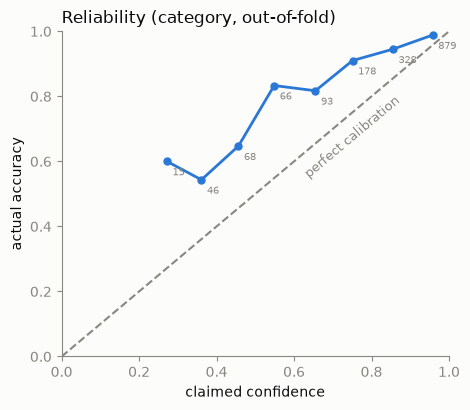

,threshold,auto_accepted,accuracy_of_accepted,flagged_for_review
0,0.3,0.991,0.929,0.009
1,0.4,0.964,0.940,0.036
2,0.5,0.923,0.953,0.077
3,0.6,0.883,0.959,0.117
4,0.7,0.828,0.968,0.172
5,0.8,0.721,0.977,0.279
6,0.9,0.525,0.989,0.475


In [10]:
proba = group_cv_predict(build_text_classifier(BEST), X, y_cat, groups, proba=True)
classes = np.array(sorted(set(y_cat)))
pred = classes[proba.argmax(axis=1)]
confidence, correct = proba.max(axis=1), pred == y_cat
table = reliability_table(confidence, correct)
print(f"ECE: {expected_calibration_error(confidence, correct):.3f}")

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1.5, linestyle="--")
ax.text(0.62, 0.55, "perfect calibration", color=MUTED, fontsize=9, rotation=40)
ax.plot(table["mean_confidence"], table["accuracy"], color=BLUE, linewidth=2, marker="o", markersize=5)
for _, r in table.iterrows():
    ax.annotate(int(r["n"]), (r["mean_confidence"], r["accuracy"]), textcoords="offset points", xytext=(4, -10), fontsize=7, color=MUTED)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("claimed confidence"); ax.set_ylabel("actual accuracy")
ax.set_title("Reliability (category, out-of-fold)", loc="left", color=INK)
plt.tight_layout(); plt.show()
threshold_table(confidence, correct)

## 7. Decisions

*(Written after running: see below.)*

DECISIONS_PLACEHOLDER